<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/gomez_vergara_5Junio/gomez_vergara_capitulo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: Juan Pablo Gómez
- Apellido2, Nombre2: Shara Vergara

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [ ]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1019604098
cedula2 = 1067869851

In [ ]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 949
Parámetros — alpha: 2.20, beta: 2.60, gamma: 0.160, ruido: 0.050
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


In [ ]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,344 kB]
Fetched 4,472 kB in 3s (1,429 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Don

---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Esto significa que a la hora de interpolar los valores, va a existir una cierta cantidad de ruido, y no cruzara necesariamente por los valores exactos

b) Es preferible usar minimos cuadrados cuando los puntos siguen una tendencia en especifico, en vez de cuando se tienen valores aleatorios. Esto nos permite ver la tendencia de los valores en lugar de generar una funcion que cruce por los valores en especifico, que puede o no ser relevante al estudio.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) La matriz A de este modelo esta dada por 3 columnas: la primera es una columna de *1s*, la segunda esta dada por una columna de valores del vector *x*, y la tercera esta dada por los valores del vector *y*.

b) El plano ajustado nos da una aproximación lineal a los valores de Z_true, y nos da informacion sobre la pendiente y, alutura y anomalias de la superficie.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Para limpiar los 0s de la función, y centrar la nube en el valor medio de los datos, y no en el punto (0,0,0)

b) Determina la direccion de la nube de puntos, el eje mas largo y la tendencia dominante de los datos

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [ ]:
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Malla fina para la evaluación
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# Evaluar el spline en la malla fina
Z_spline = spline(x_fine, y_fine)

### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

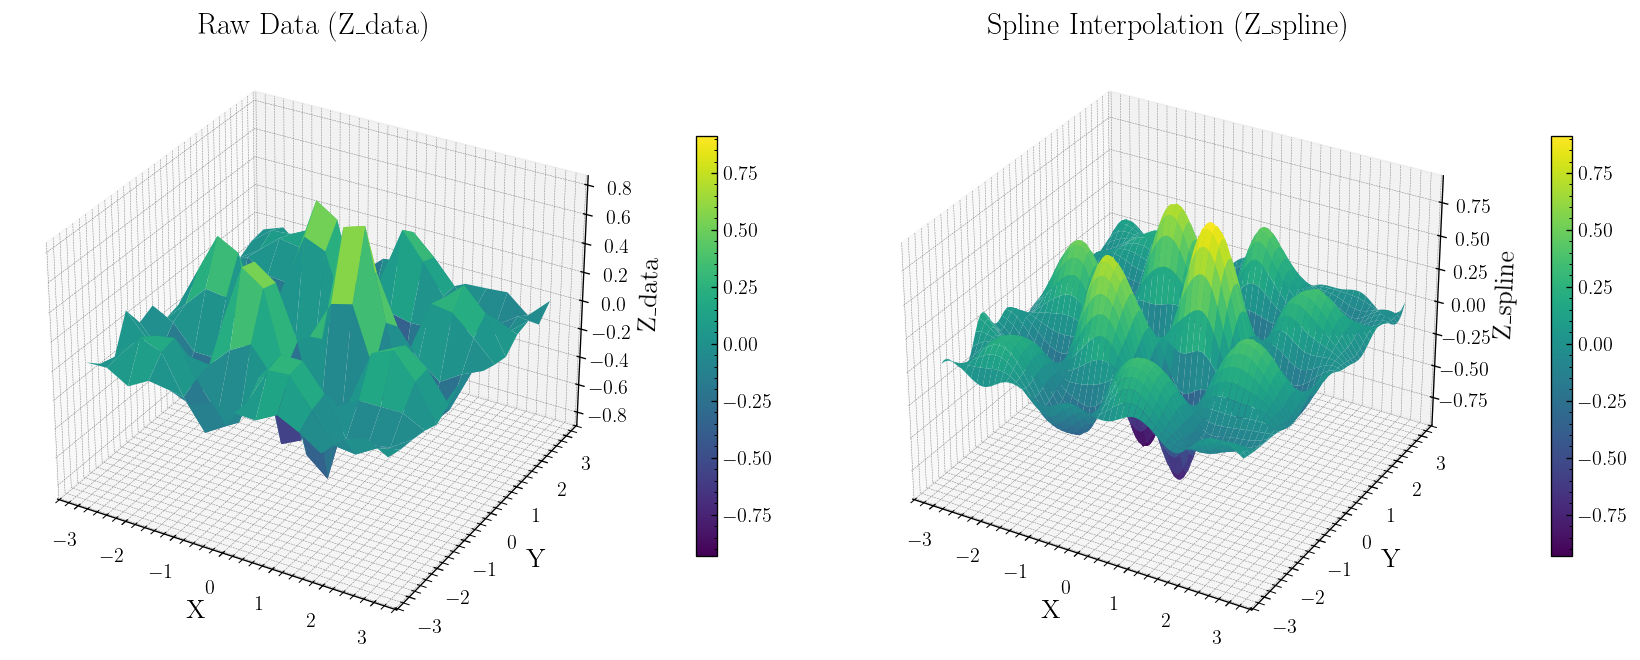

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Determinar los límites de color para ambos plots
vmin_val = min(Z_data.min(), Z_spline.min())
vmax_val = max(Z_data.max(), Z_spline.max())

fig = plt.figure(figsize=(15, 7))

# Panel izquierdo: Z_data en la malla gruesa (superficie en 3D)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', vmin=vmin_val, vmax=vmax_val)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z_data')
ax1.set_title('Raw Data (Z_data)')
fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=20, pad=0.1)

# Panel derecho: superficie interpolada por el spline en la malla fina (3D)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='viridis', vmin=vmin_val, vmax=vmax_val)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z_spline')
ax2.set_title('Spline Interpolation (Z_spline)')
fig.colorbar(surf2, ax=ax2, shrink=0.6, aspect=20, pad=0.1)

plt.tight_layout(pad=3.0)
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [ ]:
# Centrar los datos
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# Construir la matriz A
# A = [ones, x_flat, y_flat]
A = np.vstack([np.ones_like(x_flat), x_flat, y_flat]).T

# Resolver el sistema lineal
coefficients, residuals, rank, singular_values = np.linalg.lstsq(A, z_flat, rcond=None)

c0, c1, c2 = coefficients

print(f"Coeficientes del plano ajustado:")
print(f"c0 = {c0:.4f}")
print(f"c1 = {c1:.4f}")
print(f"c2 = {c2:.4f}")

Coeficientes del plano ajustado:
c0 = -0.0028
c1 = -0.0023
c2 = -0.0047


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

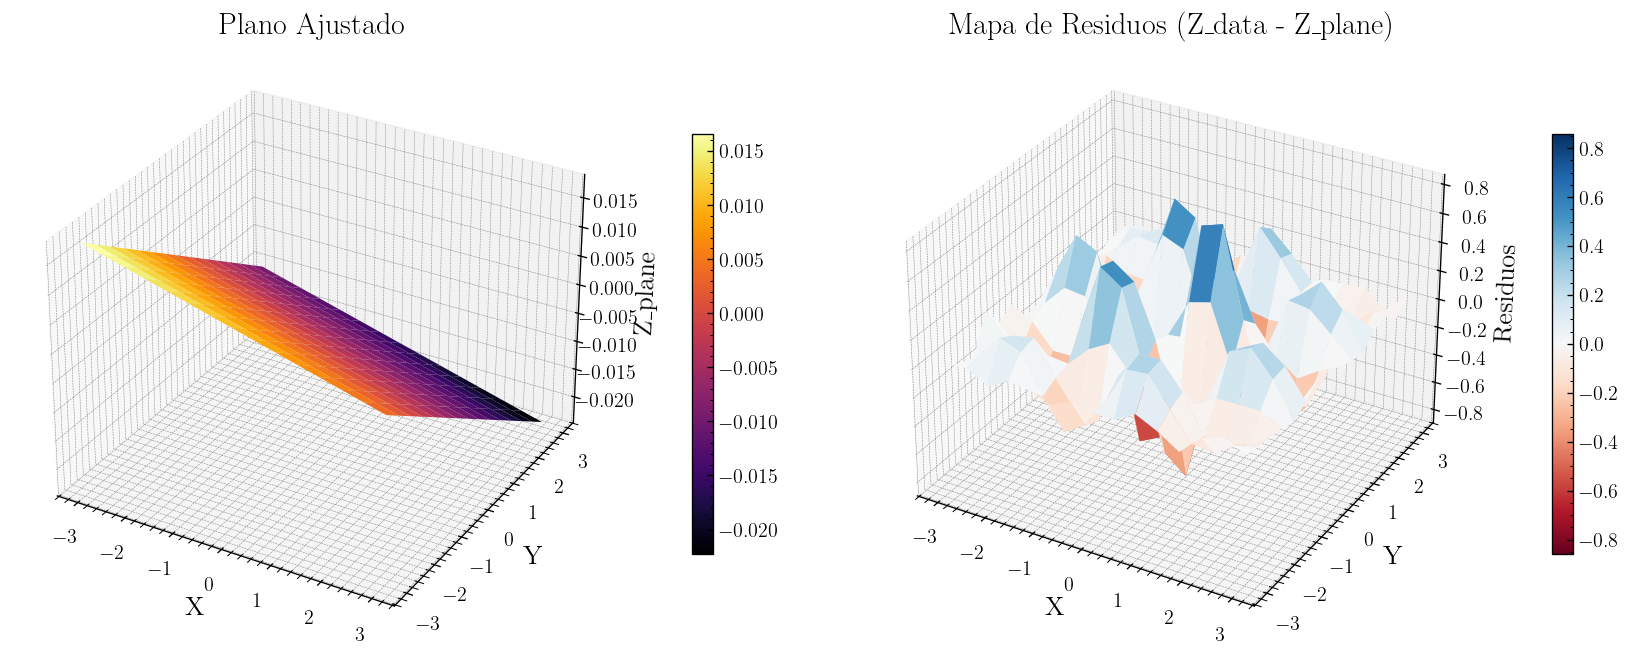

In [ ]:
# Calcular el plano ajustado en la malla gruesa
Z_plane = c0 + c1 * X_raw + c2 * Y_raw

# Calcular el mapa de residuos
R = Z_data - Z_plane

fig = plt.figure(figsize=(15, 7))

# Panel izquierdo: plano ajustado sobre la malla gruesa
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_plane, cmap='inferno')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z_plane')
ax1.set_title('Plano Ajustado')
fig.colorbar(surf1, ax=ax1, shrink=0.6, aspect=20, pad=0.1)

# Panel derecho: mapa de residuos R
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# Para un colormap divergente centrado en cero, es importante establecer vmin y vmax simétricamente
max_abs_residual = np.max(np.abs(R))
surf2 = ax2.plot_surface(X_raw, Y_raw, R, cmap='RdBu', vmin=-max_abs_residual, vmax=max_abs_residual)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Residuos')
ax2.set_title('Mapa de Residuos (Z_data - Z_plane)')
fig.colorbar(surf2, ax=ax2, shrink=0.6, aspect=20, pad=0.1)

plt.tight_layout(pad=3.0)
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [ ]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=2.20, omega2=2.60


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

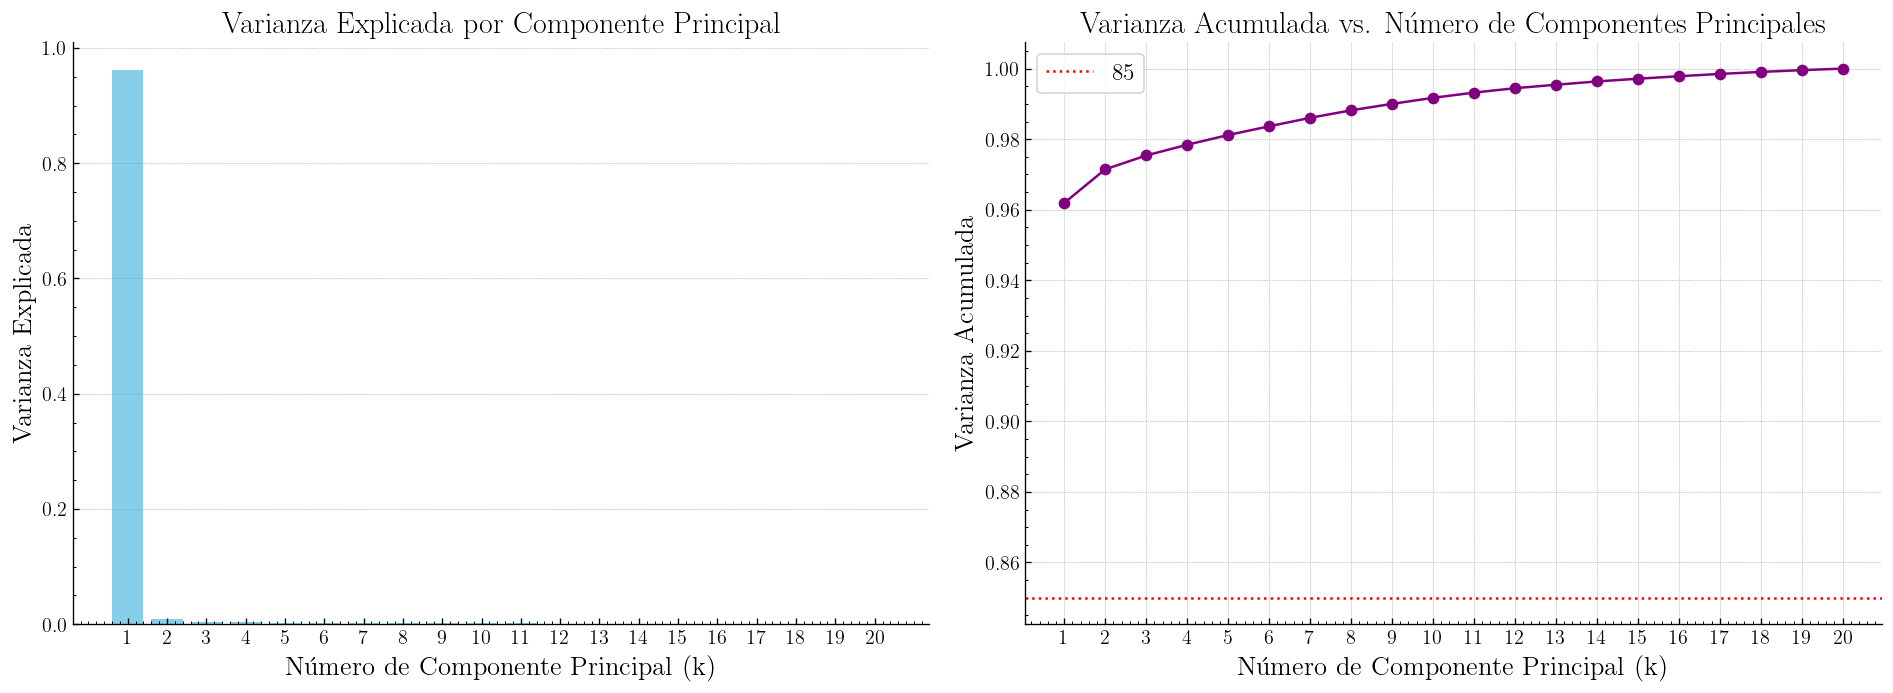

In [ ]:
X_mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - X_mean

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Calcular la varianza explicada
varianza_explicada = (S**2) / np.sum(S**2)
varianza_acumulada = np.cumsum(varianza_explicada)

k_components = np.arange(1, len(varianza_explicada) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: Varianza explicada por cada componente
axes[0].bar(k_components, varianza_explicada, color='skyblue')
axes[0].set_xlabel('Número de Componente Principal (k)')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente Principal')
axes[0].set_xticks(k_components)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel derecho: Varianza acumulada vs k
axes[1].plot(k_components, varianza_acumulada, marker='o', linestyle='-', color='purple')
axes[1].axhline(y=0.85, color='r', linestyle=':', label='85% de Varianza')
axes[1].set_xlabel('Número de Componente Principal (k)')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Varianza Acumulada vs. Número de Componentes Principales')
axes[1].set_xticks(k_components)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

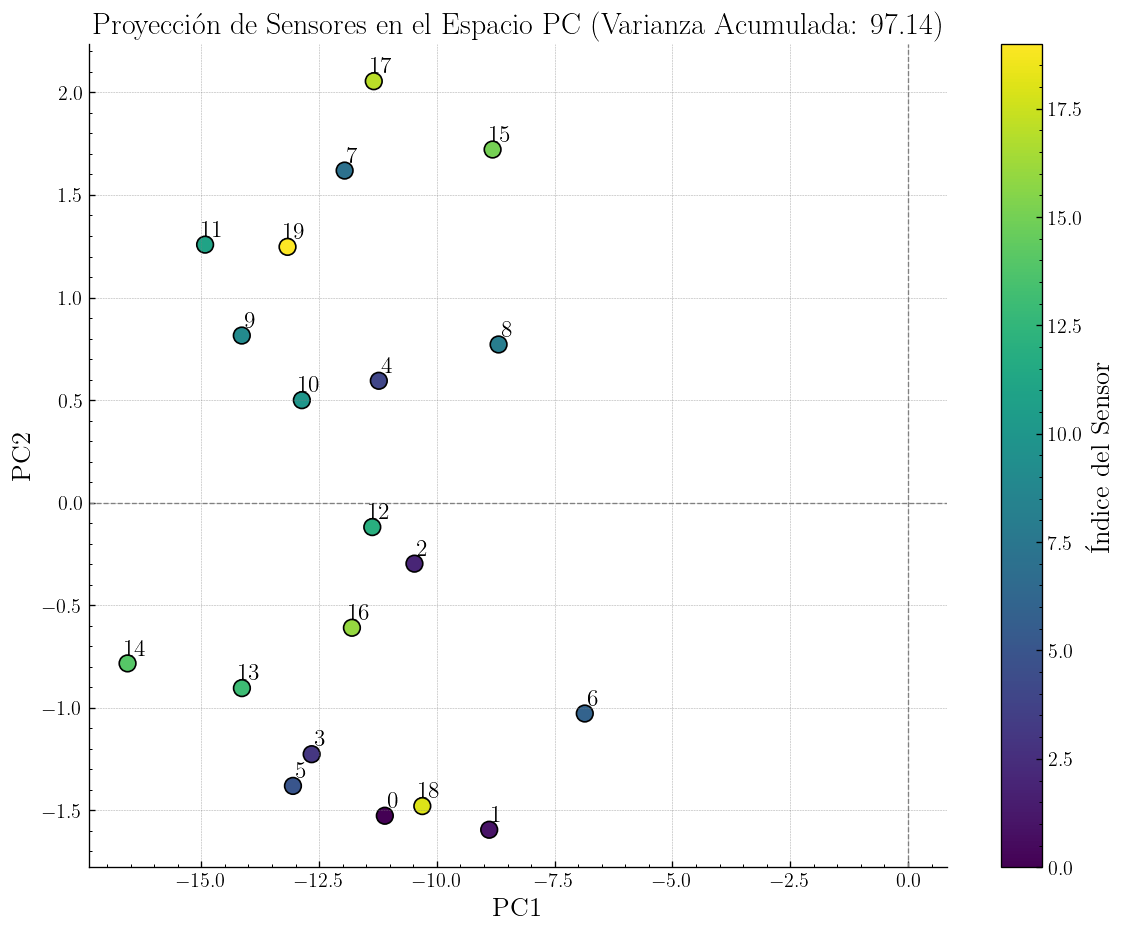

In [ ]:
k_to_use = 2 # Usando k=2 ya que es el mínimo entre 2 y 3 que explica > 89% de la varianza

# Calcular los scores proyectando los datos centrados sobre los componentes principales
# Los componentes principales son las filas de Vt
scores = X_centered @ Vt.T

# Seleccionar los scores para los k componentes elegidos
scores_selected = scores[:, :k_to_use]

# Obtener la varianza acumulada para los k componentes elegidos
accumulated_variance_k = varianza_acumulada[k_to_use - 1] * 100

# Crear índices de sensor para etiquetar y colorear
sensor_indices = np.arange(m)

if k_to_use == 2:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Gráfico de dispersión de PC1 vs PC2
    scatter = ax.scatter(scores_selected[:, 0], scores_selected[:, 1],
                         c=sensor_indices, cmap='viridis', s=100, edgecolors='k')

    # Añadir etiquetas de texto para cada sensor
    for i, txt in enumerate(sensor_indices):
        ax.annotate(str(txt), (scores_selected[i, 0], scores_selected[i, 1]),
                    textcoords="offset points", xytext=(5,5), ha='center')

    # Añadir líneas en cero
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # Establecer etiquetas de ejes y título
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Proyección de Sensores en el Espacio PC (Varianza Acumulada: {accumulated_variance_k:.2f})')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Añadir barra de color
    cbar = fig.colorbar(scatter, ax=ax, label='Índice del Sensor')
    plt.tight_layout()
    plt.show()

elif k_to_use == 3:
    # Esta parte del código se ejecutaría si k_to_use fuera 3.
    # Genera tres gráficos de dispersión: PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    pc_pairs = [(0, 1, 'PC1', 'PC2'), (0, 2, 'PC1', 'PC3'), (1, 2, 'PC2', 'PC3')]

    for i, (pc_idx1, pc_idx2, pc_name1, pc_name2) in enumerate(pc_pairs):
        ax = axes[i]
        scatter = ax.scatter(scores_selected[:, pc_idx1], scores_selected[:, pc_idx2],
                             c=sensor_indices, cmap='viridis', s=100, edgecolors='k')

        for j, txt in enumerate(sensor_indices):
            ax.annotate(str(txt), (scores_selected[j, pc_idx1], scores_selected[j, pc_idx2]),
                        textcoords="offset points", xytext=(5,5), ha='center')

        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

        ax.set_xlabel(pc_name1)
        ax.set_ylabel(pc_name2)
        ax.set_title(f'{pc_name1} vs {pc_name2} (Varianza Acumulada: {accumulated_variance_k:.2f}%)')
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.colorbar(scatter, ax=ax, label='Índice del Sensor')

    plt.tight_layout()
    plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
